<a href="https://colab.research.google.com/github/gizem-peker/python-lernen/blob/main/pandas_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files

In [10]:
import pandas as pd

In [11]:
uploaded = files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv


In [12]:
df = pd.read_csv('dirty_cafe_sales.csv')

In [13]:
print(df.shape)

(10000, 8)


In [14]:
print(df.head())

  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  


In [15]:
print (df.head(10))

  Transaction ID      Item Quantity Price Per Unit Total Spent  \
0    TXN_1961373    Coffee        2            2.0         4.0   
1    TXN_4977031      Cake        4            3.0        12.0   
2    TXN_4271903    Cookie        4            1.0       ERROR   
3    TXN_7034554     Salad        2            5.0        10.0   
4    TXN_3160411    Coffee        2            2.0         4.0   
5    TXN_2602893  Smoothie        5            4.0        20.0   
6    TXN_4433211   UNKNOWN        3            3.0         9.0   
7    TXN_6699534  Sandwich        4            4.0        16.0   
8    TXN_4717867       NaN        5            3.0        15.0   
9    TXN_2064365  Sandwich        5            4.0        20.0   

   Payment Method  Location Transaction Date  
0     Credit Card  Takeaway       2023-09-08  
1            Cash  In-store       2023-05-16  
2     Credit Card  In-store       2023-07-19  
3         UNKNOWN   UNKNOWN       2023-04-27  
4  Digital Wallet  In-store       2023

In [16]:
print(df.tail())

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
9995    TXN_7672686    Coffee        2            2.0         4.0   
9996    TXN_9659401       NaN        3            NaN         3.0   
9997    TXN_5255387    Coffee        4            2.0         8.0   
9998    TXN_7695629    Cookie        3            NaN         3.0   
9999    TXN_6170729  Sandwich        3            4.0        12.0   

      Payment Method  Location Transaction Date  
9995             NaN   UNKNOWN       2023-08-30  
9996  Digital Wallet       NaN       2023-06-02  
9997  Digital Wallet       NaN       2023-03-02  
9998  Digital Wallet       NaN       2023-12-02  
9999            Cash  In-store       2023-11-07  


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [18]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [19]:
# Check column names
print(df.columns.tolist())

['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [20]:
# Check for missing values per column
print(df.isnull().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [21]:
# Select one column
print(df['Item'])

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: object


In [22]:
print(df[['Item', 'Quantity', 'Price Per Unit']])

          Item Quantity Price Per Unit
0       Coffee        2            2.0
1         Cake        4            3.0
2       Cookie        4            1.0
3        Salad        2            5.0
4       Coffee        2            2.0
...        ...      ...            ...
9995    Coffee        2            2.0
9996       NaN        3            NaN
9997    Coffee        4            2.0
9998    Cookie        3            NaN
9999  Sandwich        3            4.0

[10000 rows x 3 columns]


In [23]:
cash_sales = df[df['Payment Method'] == 'Cash']

In [24]:
print(cash_sales.head())

   Transaction ID      Item Quantity Price Per Unit Total Spent  \
1     TXN_4977031      Cake        4            3.0        12.0   
7     TXN_6699534  Sandwich        4            4.0        16.0   
10    TXN_2548360     Salad        5            5.0        25.0   
12    TXN_7619095  Sandwich        2            4.0         8.0   
17    TXN_6769710     Juice        2            3.0         6.0   

   Payment Method  Location Transaction Date  
1            Cash  In-store       2023-05-16  
7            Cash   UNKNOWN       2023-10-28  
10           Cash  Takeaway       2023-11-07  
12           Cash  In-store       2023-05-03  
17           Cash  In-store       2023-02-24  


In [25]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [26]:
# This cell filters for high-value transactions based on 'Price Per Unit' and 'Quantity'.
high_value = df[(df['Price Per Unit'] > 3) & (df['Quantity'] > 2)]

In [27]:
print(high_value.shape)

(2033, 8)


In [23]:
# Replace 'UNKNOWN' and 'ERROR' with NaN (proper missing value marker)
df = df.replace(['UNKNOWN', 'ERROR'], pd.NA)


In [28]:
# Check how many nulls we now have
print(df.isnull().sum())

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [29]:
# Drop rows where key columns are missing
df = df.dropna(subset=['Item', 'Price Per Unit', 'Quantity'])

In [30]:
# Create a Total Sales column
df['Total Sales'] = df['Price Per Unit'] * df['Quantity']

In [31]:
print(df.shape)

(8713, 9)


In [32]:
# What items sell most?
print(df['Item'].value_counts().head(10))


Item
Juice       1063
Coffee      1048
Cake        1042
Salad       1030
Sandwich    1022
Smoothie     994
Cookie       976
Tea          972
UNKNOWN      304
ERROR        262
Name: count, dtype: int64


In [33]:
# What is the total revenue?
print(df['Total Sales'].sum())

77827.5


In [34]:
# What is the average transaction value?
print(df['Total Sales'].mean().round(2))

8.93


In [35]:
# Revenue by payment method
# Note: rows with missing Payment Method are excluded from groupby automatically
print(df.groupby('Payment Method')['Total Sales'].sum().sort_values(ascending=False))

Payment Method
Cash              17917.5
Digital Wallet    17871.0
Credit Card       17737.0
ERROR              2355.0
UNKNOWN            2261.5
Name: Total Sales, dtype: float64


In [36]:
# Revenue by item
print(df.groupby('Item')['Total Sales'].sum().sort_values(ascending=False).head(10))

Item
Salad       15600.0
Sandwich    12296.0
Smoothie    12132.0
Juice        9561.0
Cake         9540.0
Coffee       6424.0
Tea          4431.0
Cookie       2898.0
UNKNOWN      2550.0
ERROR        2395.5
Name: Total Sales, dtype: float64


In [37]:
df.to_csv('cafe_sales_clean.csv', index=False)

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

/tmp/ipykernel_13297/1061955734.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=item_sales.index, y=item_sales.values, palette='viridis')


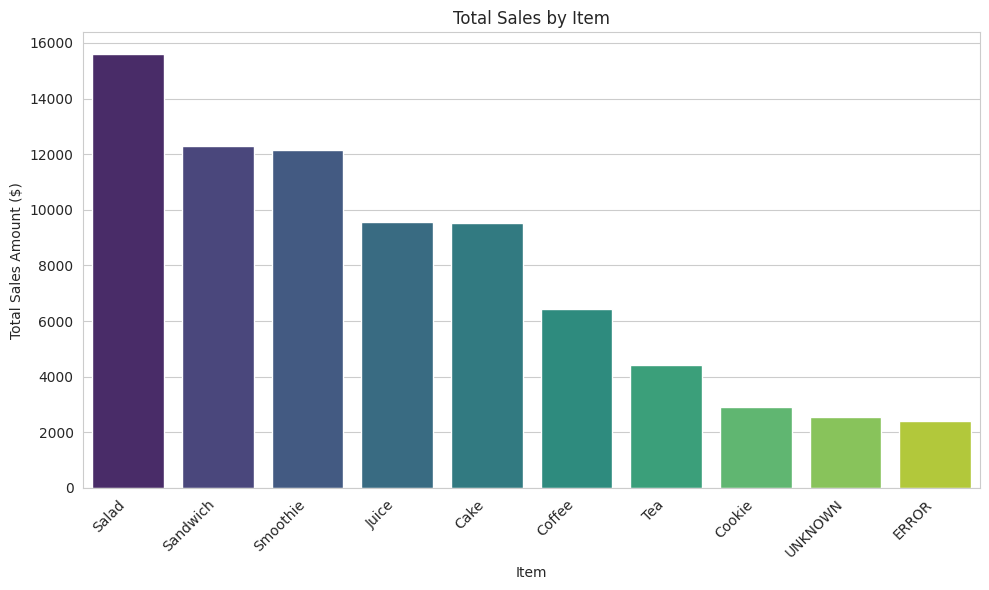

In [48]:
# Style adjustment for better looking plots
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
# Bar chart showing top-selling items by Total Sales
item_sales = df.groupby('Item')['Total Sales'].sum().sort_values(ascending=False)
sns.barplot(x=item_sales.index, y=item_sales.values, palette='viridis')
plt.title('Total Sales by Item')
plt.xlabel('Item')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_13297/1298563248.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_method_sales.index, y=payment_method_sales.values, palette='coolwarm')


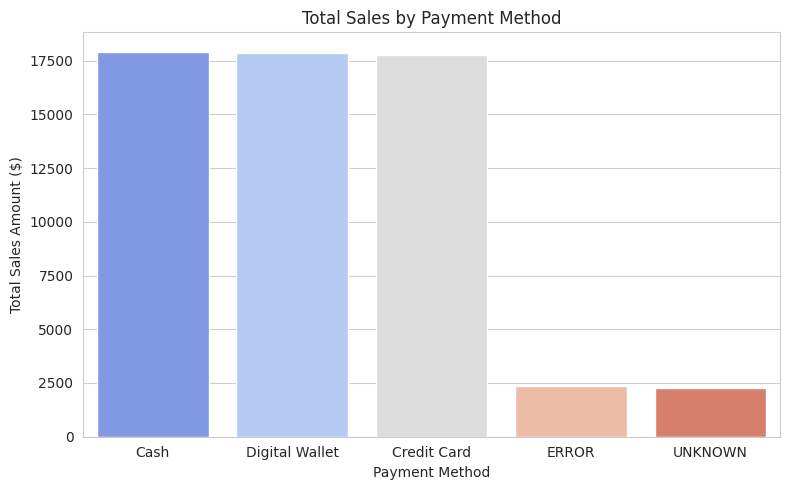

In [47]:
plt.figure(figsize=(8, 5))

# Bar chart showing total sales by payment method
payment_method_sales = df.groupby('Payment Method')['Total Sales'].sum().sort_values(ascending=False)
sns.barplot(x=payment_method_sales.index, y=payment_method_sales.values, palette='coolwarm')

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

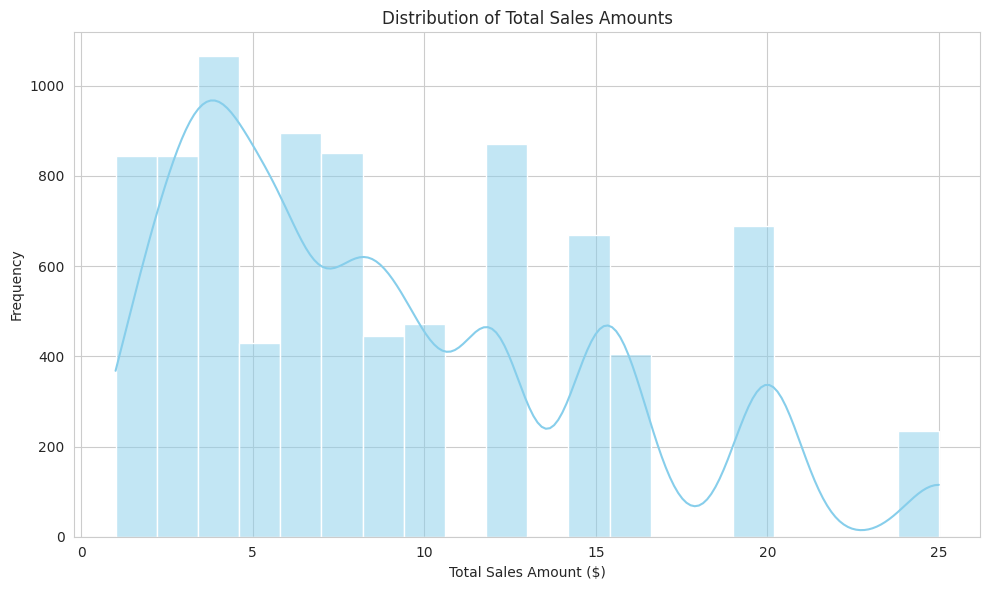

In [50]:
plt.figure(figsize=(10, 6))

# Histogram showing the distribution of the Total Sales column
sns.histplot(df['Total Sales'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Total Sales Amounts')
plt.xlabel('Total Sales Amount ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()